<a href="https://colab.research.google.com/github/silvatria/PCVK_Ganjil_2026/blob/main/JS-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Mengakses Gambar dari Google Drive atau Upload Lokal
# Menghubungkan ke Google Drive:

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


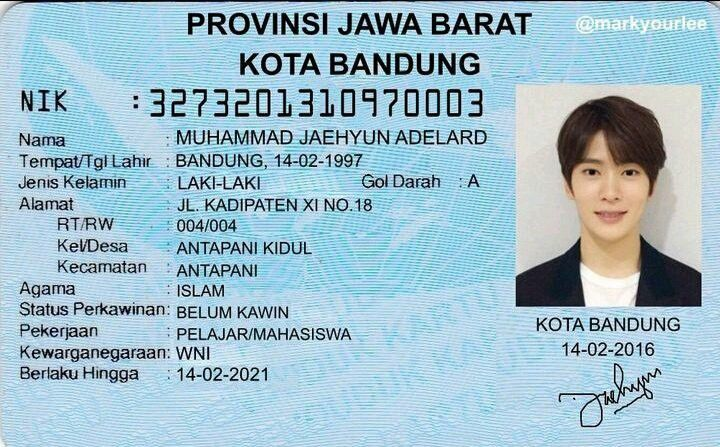

Resolusi gambar:  720 x 447


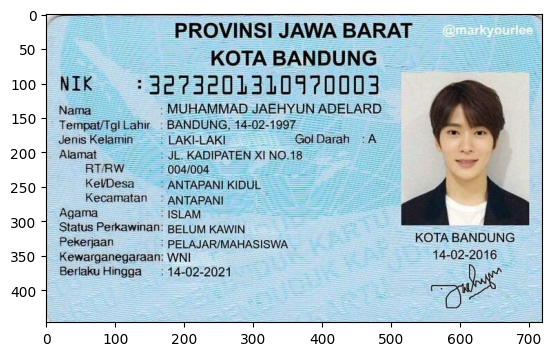

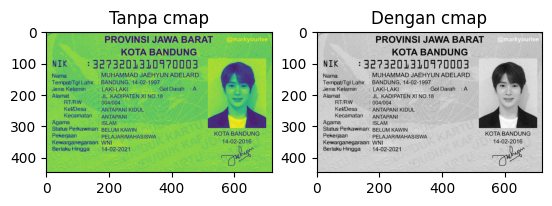

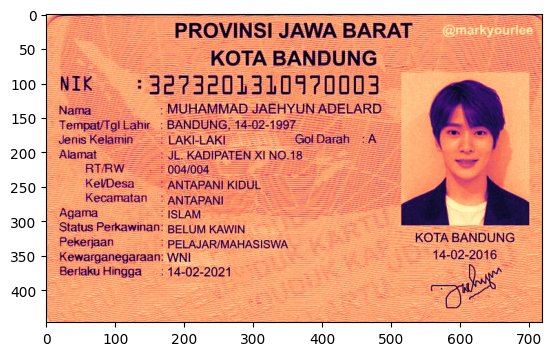

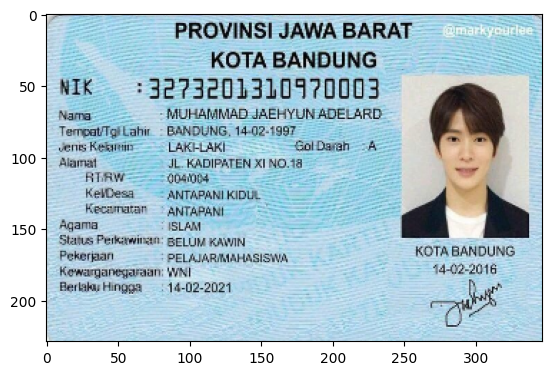

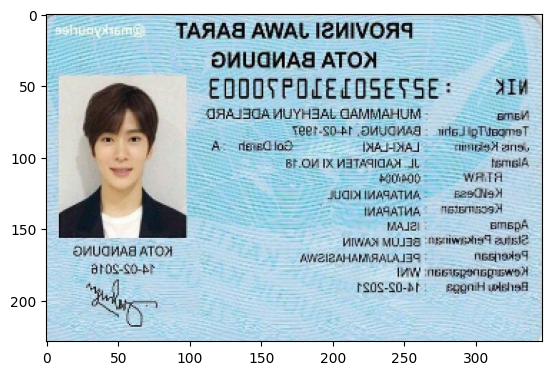

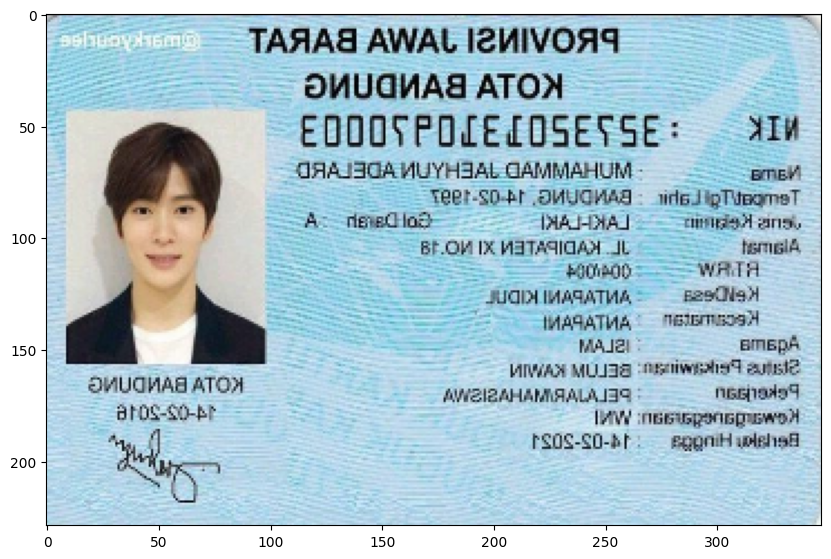

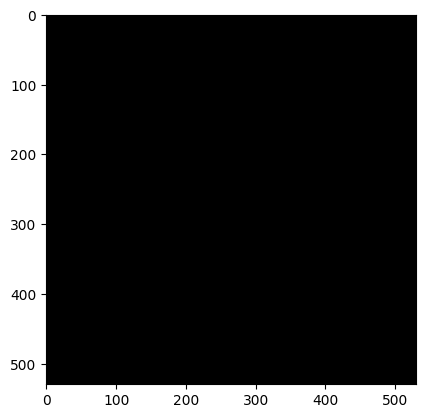

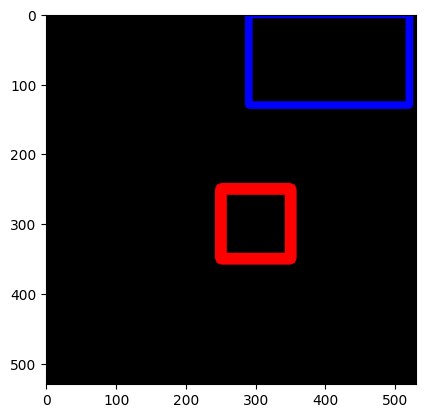

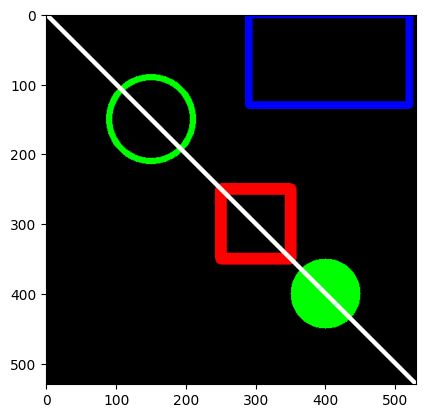

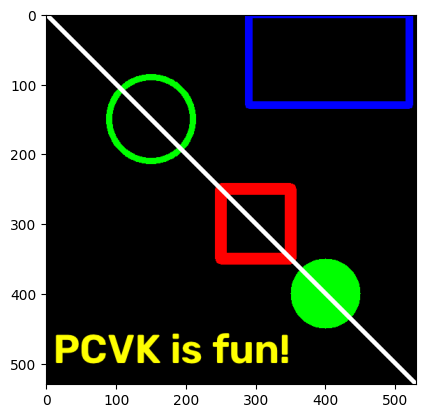

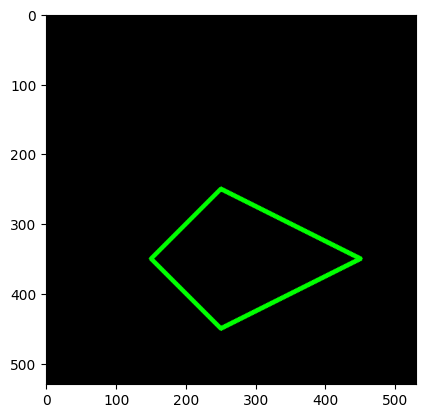

In [20]:
# Mengakses gambar dengan fungsi upload file:
# from google.colab import files
# uploaded = files.upload()

# Menampilkan gambar dan resolusinya:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktp.jpg')
cv2_imshow(img)
print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

# 2. Menampilkan Gambar (Image Display & Plotting)
# Menampilkan menggunakan Matplotlib (Format BGR bawaan OpenCV):
img = cv.imread('ktp.jpg')
plt.imshow(img) # format warna BGR

# Konversi kanal BGR ke RGB agar warna sesuai aslinya
img = cv.imread('ktp.jpg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) # konversi channel BGR -> RGB
plt.imshow(img2)

# Atau langsung digabung:
img = cv.imread('ktp.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) # konversi channel BGR -> RGB
plt.show()

# 3. Menampilkan Citra Grayscale (Keabuan)
img_gray = cv.imread('ktp.jpg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')
plt.show()

# Menggunakan colormap 'magma':
plt.imshow(img_gray, cmap='magma')
plt.show()

# 4. Melakukan Resizing (Pengubahan Ukuran)
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) # konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)
plt.show()

# 5. Melakukan Flipping (Pencerminan)
# Pencerminan horizontal:
imgFlip = cv.flip(img_output, 1)
plt.imshow(imgFlip)
plt.show()
# Memperbesar ukuran canvas menggunakan figure:
imgFlip = cv.flip(img_output, 1)

# Tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(imgFlip)
plt.show()

# 6. Membuat Bentuk Geometri 2D & Teks dari OpenCV
# Membuat kanvas hitam awal:
black_img = np.zeros(shape=(530, 530, 3), dtype=np.uint8)
plt.imshow(black_img)
plt.show()

# Menambahkan Rectangle (Persegi Panjang 1 & 2):
cv.rectangle(black_img, pt1=(290, 0), pt2=(520, 130), color=(0, 0, 255), thickness=10)
cv.rectangle(black_img, pt1=(250, 250), pt2=(350, 350), color=(255, 0, 0), thickness=15)
plt.imshow(black_img)
plt.show()

# Menambahkan Lingkaran dan Garis Lurus:
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)
plt.show()

# Menambahkan Teks:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10, 500), fontFace=font, fontScale=2,
           color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)
plt.show()

# Membuat Polylines dengan tipe data int32:
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)

vertices = np.array([[150, 350], [250, 250], [450, 350], [250, 450]], dtype=np.int32)
pts = vertices.reshape((-1, 1, 2))

cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)
plt.imshow(black_img2)
plt.show()



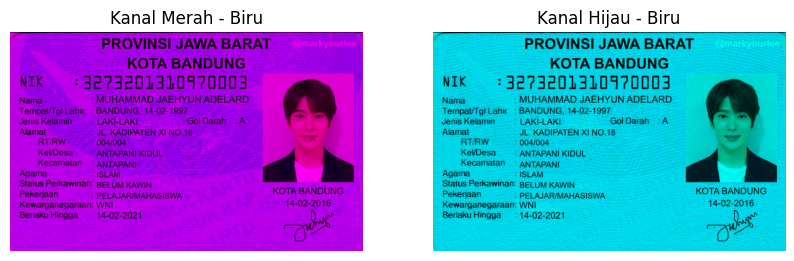

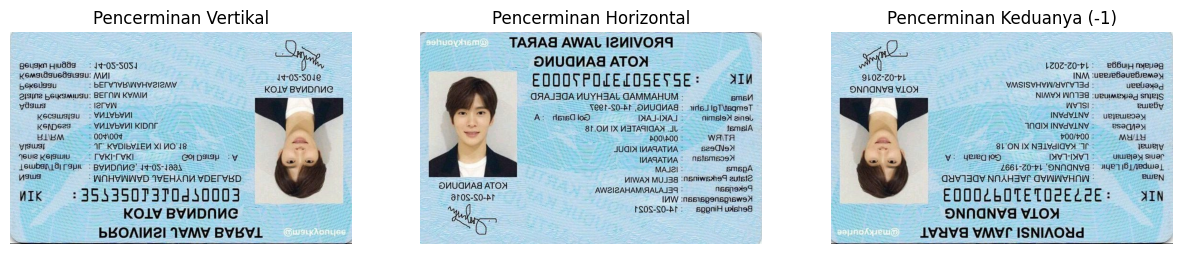

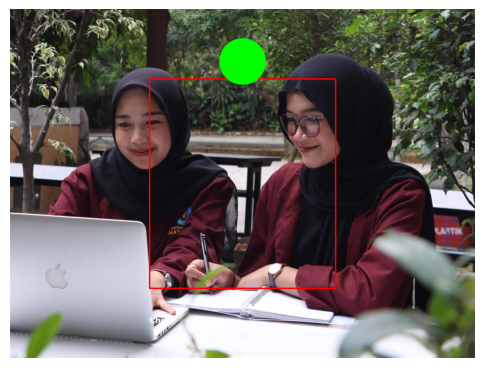

In [24]:
# TUGAS PRAKTIKUM - Penerapan
# Kombinasi Kanal Merah-Biru dan Hijau-Biru:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Baca citra asli (dalam format BGR)
img = cv.imread('ktp.jpg')

# Buat salinan untuk manipulasi kanal
img_mb = img.copy()  # Merah-Biru (Hijau dinolkan)
img_gb = img.copy()  # Hijau-Biru (Merah dinolkan)

# Nolkan kanal Hijau (indeks 1) pada img_mb -> tersisa Merah (indeks 2) dan Biru (indeks 0)
img_mb[:, :, 1] = 0

# Nolkan kanal Merah (indeks 2) pada img_gb -> tersisa Hijau (indeks 1) dan Biru (indeks 0)
img_gb[:, :, 2] = 0

# Tampilkan berdampingan dalam satu figure
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_mb, cv.COLOR_BGR2RGB))
plt.title('Kanal Merah - Biru')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_gb, cv.COLOR_BGR2RGB))
plt.title('Kanal Hijau - Biru')
plt.axis('off')

plt.show()

# Tiga Bentuk Pencerminan (Vertikal, Horizontal, Keduanya):
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('ktp.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pencerminan: 0 = Vertikal, 1 = Horizontal, -1 = Keduanya
flip_vertikal = cv.flip(img_rgb, 0)
flip_horizontal = cv.flip(img_rgb, 1)
flip_keduanya = cv.flip(img_rgb, -1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(flip_vertikal)
plt.title('Pencerminan Vertikal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title('Pencerminan Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_keduanya)
plt.title('Pencerminan Keduanya (-1)')
plt.axis('off')

plt.show()

# Menggambar Rectangle, Circle, dan Text pada Foto Aktivitas Sendiri:
import cv2 as cv
import matplotlib.pyplot as plt

# Ganti 'aktivitas.jpg' dengan nama file foto Anda
img_act = cv.imread('aktivitas.jpeg')
img_act_rgb = cv.cvtColor(img_act, cv.COLOR_BGR2RGB)

# Contoh koordinat adaptif berdasarkan ukuran gambar (atau koordinat manual area wajah/badan)
h, w = img_act_rgb.shape[:2]

# Menggambar Rectangle di area wajah/badan (contoh koordinat proporsional)
cv.rectangle(img_act_rgb, pt1=(int(w*0.3), int(h*0.2)), pt2=(int(w*0.7), int(h*0.8)), color=(255, 0, 0), thickness=3)

# Menggambar Circle di dekat objek
cv.circle(img_act_rgb, center=(int(w*0.5), int(h*0.15)), radius=int(w*0.05), color=(0, 255, 0), thickness=-1)

# Menambahkan Teks Nama Anda
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_act_rgb, text='Chen', org=(int(w*0.3), int(h*0.9)), fontFace=font, fontScale=1,
           color=(255, 255, 255), thickness=2, lineType=cv.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(img_act_rgb)
plt.axis('off')
plt.show()


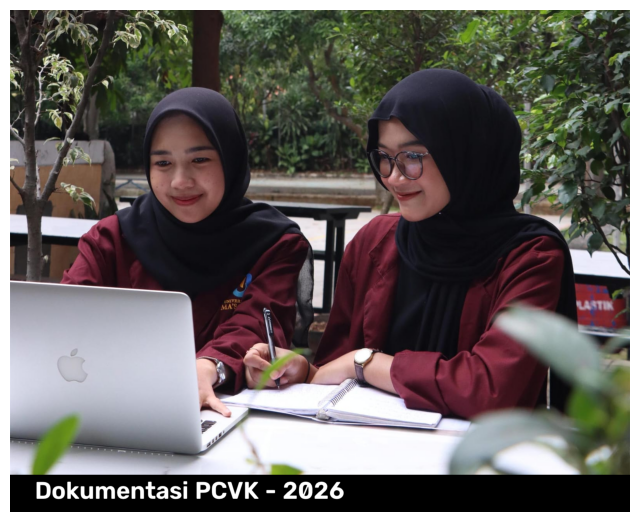

In [43]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

def beri_label_adaptif_universal(image_path, teks_label):
    img = cv.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"File gambar '{image_path}' tidak ditemukan!")

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Tinggi bar dikalkulasi dari lebar (w) atau tinggi minimum agar konsisten di portrait/landscape
    # Kita jadikan proporsional terhadap dimensi yang lebih kecil (biasanya lebar)
    bar_height = max(40, int(h * 0.08))

    # Buat kanvas baru yang sedikit ditambah tinggi ke bawah khusus buat bar label
    kanvas_baru = np.zeros((h + bar_height, w, 3), dtype=np.uint8)

    # Tempel foto asli di bagian atas
    kanvas_baru[0:h, 0:w] = img_rgb

    # Buat bar hitam di area tambahan bagian bawah
    cv.rectangle(kanvas_baru, pt1=(0, h), pt2=(w, h + bar_height), color=(0, 0, 0), thickness=-1)

    # Sesuaikan ukuran font dan ketebalan secara proporsional berdasarkan bar_height
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.4, (bar_height / 45.0))
    thickness = max(1, int(bar_height / 18))

    # Hitung posisi teks supaya pas di tengah-tengah bar hitam secara vertikal
    text_y = h + int(bar_height * 0.65)
    text_x = int(w * 0.04) # Padding kiri

    cv.putText(kanvas_baru, text=teks_label, org=(text_x, text_y),
               fontFace=font, fontScale=font_scale, color=(255, 255, 255),
               thickness=thickness, lineType=cv.LINE_AA)

    return kanvas_baru

res_final = beri_label_adaptif_universal('aktivitas.jpeg', 'Dokumentasi PCVK - 2026')

plt.figure(figsize=(8, 10))
plt.imshow(res_final)
plt.axis('off')
plt.show()

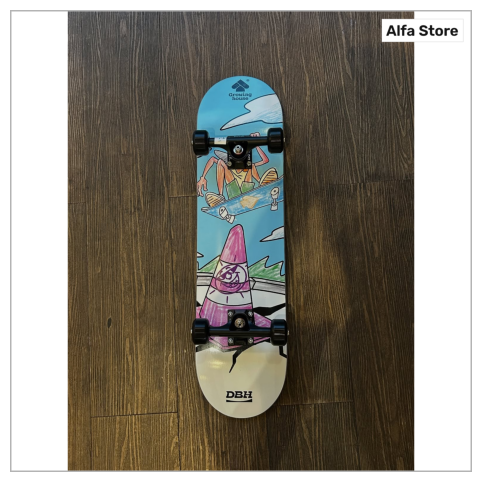

In [52]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

def buat_thumbnail_marketplace_fix(image_path, nama_toko="Toko Berkah 2026"):
    img = cv.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"File gambar '{image_path}' tidak ditemukan!")

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # 1. Buat ukuran sisi kanvas persegi berdasarkan nilai terbesar (tinggi / lebar)
    sisi = max(h, w)

    # 2. Buat kanvas kosong 1:1 penuh warna putih
    kanvas = np.full((sisi, sisi, 3), 255, dtype=np.uint8)

    # 3. Hitung posisi tengah agar foto asli pas di tengah-tengah kanvas persegi
    y_off = (sisi - h) // 2
    x_off = (sisi - w) // 2

    # Tempel foto asli ke tengah kanvas
    kanvas[y_off:y_off+h, x_off:x_off+w] = img_rgb

    cv.rectangle(kanvas, pt1=(0, 0), pt2=(sisi-1, sisi-1), color=(180, 180, 180), thickness=max(2, sisi // 200))

    # 4. Tambahkan badge logo toko di pojok kanan atas
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.5, sisi / 900.0)
    thickness = max(1, int(sisi / 300))

    text_size, _ = cv.getTextSize(nama_toko, font, font_scale, thickness)

    padding_box = 15
    box_w = text_size[0] + (padding_box * 2)
    box_h = text_size[1] + (padding_box * 2)

    x2 = sisi - 30
    x1 = x2 - box_w
    y1 = 30
    y2 = y1 + box_h

    # Background badge putih & border tipis
    cv.rectangle(kanvas, pt1=(x1, y1), pt2=(x2, y2), color=(255, 255, 255), thickness=-1)
    cv.rectangle(kanvas, pt1=(x1, y1), pt2=(x2, y2), color=(200, 200, 200), thickness=1)

    # Cetak teks nama toko
    text_x = x1 + padding_box
    text_y = y2 - padding_box - 5
    cv.putText(kanvas, text=nama_toko, org=(text_x, text_y),
               fontFace=font, fontScale=font_scale, color=(20, 20, 20),
               thickness=thickness, lineType=cv.LINE_AA)

    return kanvas

res_marketplace = buat_thumbnail_marketplace_fix('produk.jpg', 'Alfa Store')

plt.figure(figsize=(6, 6))
plt.imshow(res_marketplace)
plt.gca().set_aspect('equal') # Memaksa sumbu X dan Y proporsional 1:1
plt.axis('off')
plt.show()

In [54]:
# 1

import cv2 as cv
import matplotlib.pyplot as plt

# Baca citra
img = cv.imread('ktp.jpg')

# Ambil nilai piksel pada koordinat baris ke-100, kolom ke-100
y, x = 100, 100
nilai_piksel = img[y, x]

print(f"Nilai piksel pada koordinat [{y}, {x}] (Format BGR OpenCV):")
print(f"Blue={nilai_piksel[0]}, Green={nilai_piksel[1]}, Red={nilai_piksel[2]}")

print('\n')
# 2

import numpy as np

# Buat kanvas hitam int16 dan int32 dengan ukuran sama
canvas_16 = np.zeros(shape=(530, 530, 3), dtype=np.int16)
canvas_32 = np.zeros(shape=(530, 530, 3), dtype=np.int32)

print("--- KANVAS INT16 ---")
print("dtype :", canvas_16.dtype)
print("min   :", canvas_16.min())
print("max   :", canvas_16.max())
print("nbytes:", canvas_16.nbytes, "bytes")

print("\n--- KANVAS INT32 ---")
print("dtype :", canvas_32.dtype)
print("min   :", canvas_32.min())
print("max   :", canvas_32.max())
print("nbytes:", canvas_32.nbytes, "bytes")

Nilai piksel pada koordinat [100, 100] (Format BGR OpenCV):
Blue=219, Green=203, Red=174
--- KANVAS INT16 ---
dtype : int16
min   : 0
max   : 0
nbytes: 1685400 bytes

--- KANVAS INT32 ---
dtype : int32
min   : 0
max   : 0
nbytes: 3370800 bytes
